In [1]:
import numpy as np
import os
from cil.io import TIFFStackReader
from cil.utilities.jupyter import islicer
import matplotlib.pyplot as plt
import glob

import numpy as np
import matplotlib.pyplot as plt
import os

# import warnings
# warnings.filterwarnings("ignore")

from cil.utilities.display import show2D
from cil.utilities.display import show1D
from cil.utilities.jupyter import islicer, link_islicer
from cil.plugins.astra import FBP as FBP_ASTRA
from cil.processors import Slicer 
from cil.framework import DataContainer

from data_io.io import read_mantid_imaging_data
from utils.masks import create_ring_mask
from utils.metrics import calculate_L2Norm_error, calculate_snr, calculate_cnr
from recon.weighted_fbp import run_weighted_fbp_parallel

In [2]:
from cil.utilities.display import show1D, show2D
from cil.processors import Slicer
from cil.plugins.astra import ProjectionOperator
import numpy as np
import matplotlib.pyplot as plt
import os

from cil.optimisation.algorithms import PDHG
from cil.io import TIFFWriter, TIFFStackReader
from cil.utilities.jupyter import islicer
from cil.framework import DataContainer

# set up TGV
from cil.optimisation.functions import MixedL21Norm, BlockFunction, L2NormSquared, ZeroFunction
from cil.optimisation.operators import BlockOperator, GradientOperator
from cil.optimisation.functions import L2NormSquared, IndicatorBox
# from pdhg_utils import setup_explicit_TV

import os

from recon.weighted_fbp import run_weighted_fbp_parallel

In [3]:
# Update this path to where you have downloaded the data:
base_path = "/home/lhe97136/Data/Lego GR Investigation/Data for Release/preprocessed_data/"
# read in the equi data and recon the slice of interest:
# pixel size in cm, which is listed on the zenodo page:
pixel_size = 100*10**-4
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=pixel_size)
gr_full = read_mantid_imaging_data(os.path.join(base_path, "Golden_Ratio"), pixel_size=pixel_size)

# exclude the duplicate projection from the full equidistant data:
equi_full_slice = equi_full.get_slice(vertical=317)
equi_full.reorder('astra')
equi_full_recon = run_weighted_fbp_parallel(equi_full_slice)

/home/lhe97136/CIL-IMAT-Correct/IMAT-Demos/recon/weighted_fbp.py:114: UserWarning: Because max_gap was None, it has been set to double the mean of all gaps between angles: 0.7860 degree
  return _calculate_angular_sampling_weights(data, 180, max_gap, wedge_behaviour)


In [4]:
gr_fbps = []
gr_scales = [0.25, 0.5, 0.75]
gr_slices = []
for gr_scale in gr_scales:
    gr_slice = Slicer(roi={'angle':(0,457*gr_scale), 'vertical':(317,318)})(gr_full)
    gr_slices.append(gr_slice)
    recon_reduced_gr_weighted = run_weighted_fbp_parallel(gr_slice)
    gr_fbps.append(recon_reduced_gr_weighted)

/home/lhe97136/CIL-IMAT-Correct/IMAT-Demos/recon/weighted_fbp.py:114: UserWarning: Because max_gap was None, it has been set to double the mean of all gaps between angles: 3.1579 degree
  return _calculate_angular_sampling_weights(data, 180, max_gap, wedge_behaviour)
/home/lhe97136/CIL-IMAT-Correct/IMAT-Demos/recon/weighted_fbp.py:114: UserWarning: Because max_gap was None, it has been set to double the mean of all gaps between angles: 1.5789 degree
  return _calculate_angular_sampling_weights(data, 180, max_gap, wedge_behaviour)
/home/lhe97136/CIL-IMAT-Correct/IMAT-Demos/recon/weighted_fbp.py:114: UserWarning: Because max_gap was None, it has been set to double the mean of all gaps between angles: 1.0526 degree
  return _calculate_angular_sampling_weights(data, 180, max_gap, wedge_behaviour)


In [5]:
# 
# ad = gr_slices[0]
# ag = ad.geometry
# ig = ag.get_ImageGeometry()
# A = ProjectionOperator(ig, ag, device="gpu")

# K, F = setup_explicit_TV(A, 0.005, ad, omega=1)
# G = ZeroFunction()
# normK = K.norm()
# sigma = 1
# tau = 1 / (sigma * normK**2)

# myPDHG_explicit = PDHG(f=F, 
#         g=G,
#         sigma = sigma,
#         tau=tau, 
#         operator=K, 
#         update_objective_interval = 1)

# myPDHG_explicit.run(5000)
    

In [6]:
# ad = gr_slices[0]
# ag = ad.geometry
# ig = ag.get_ImageGeometry()
# A = ProjectionOperator(ig, ag, device="gpu")

# K, F = setup_explicit_TV(A, 0.005, ad, omega=1)
# G = ZeroFunction()
# normK = K.norm()
# sigma = 1
# tau = 1 / (sigma * normK**2)
# G = IndicatorBox(lower=0)

# myPDHG_explicit_NN = PDHG(f=F,g=G,
#         sigma = sigma,
#         tau=tau, 
#         operator=K, 
#         update_objective_interval = 100)
# myPDHG_explicit_NN.run(5000,verbose=2)

In [13]:
from pdhg_utils import setup_explicit_TV
ad = gr_slices[0]
ag = ad.geometry
ig = ag.get_ImageGeometry()
A = ProjectionOperator(ig, ag, device="gpu")

K, F = setup_explicit_TV(A, None, ad, omega=1, alpha=1e-4)
G = ZeroFunction()
normK = K.norm()
sigma = 1
tau = 1 / (sigma * normK**2)
G = IndicatorBox(lower=0)

myPDHG_explicit_NN2 = PDHG(f=F,g=G,
        sigma = sigma,
        tau=tau, 
        operator=K, 
        update_objective_interval = 100)
myPDHG_explicit_NN2.run(5000,verbose=2)

alpha =  0.0001


  0%|          | 0/5000 [00:00<?, ?it/s]

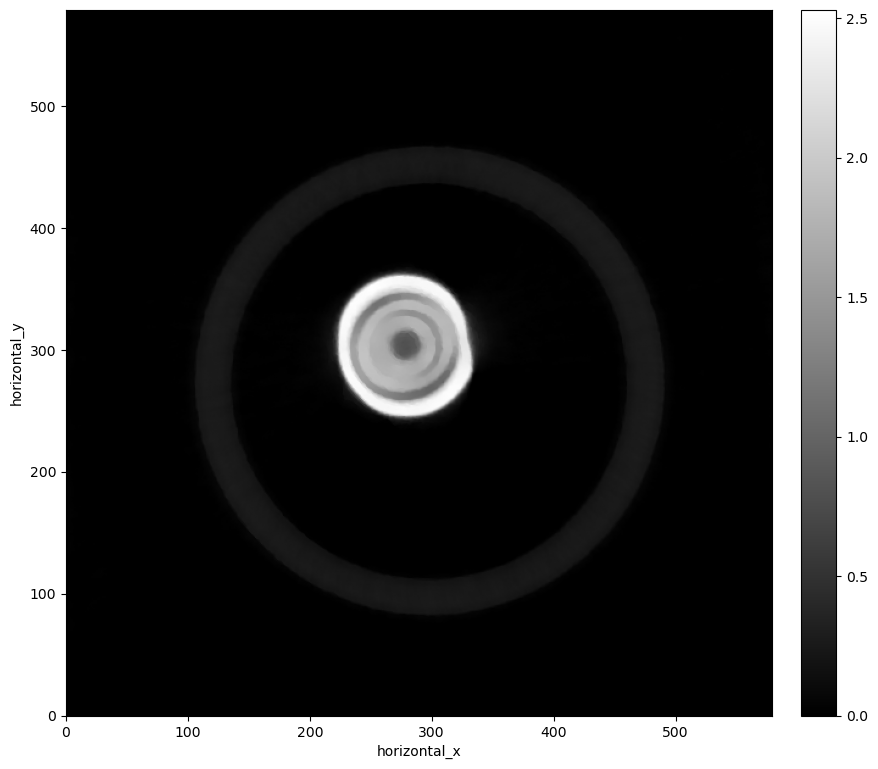

In [14]:
show2D(myPDHG_explicit_NN2.solution)

In [15]:
from pdhg_utils import setup_explicit_TV
ad = gr_slices[0]
ag = ad.geometry
ig = ag.get_ImageGeometry()
A = ProjectionOperator(ig, ag, device="gpu")

K, F = setup_explicit_TV(A, None, ad, omega=1, alpha=1e-5)
G = ZeroFunction()
normK = K.norm()
sigma = 1
tau = 1 / (sigma * normK**2)
G = IndicatorBox(lower=0)

myPDHG_explicit_NN3 = PDHG(f=F,g=G,
        sigma = sigma,
        tau=tau, 
        operator=K, 
        update_objective_interval = 100)
myPDHG_explicit_NN3.run(5000,verbose=2)

alpha =  1e-05


  0%|          | 0/5000 [00:00<?, ?it/s]

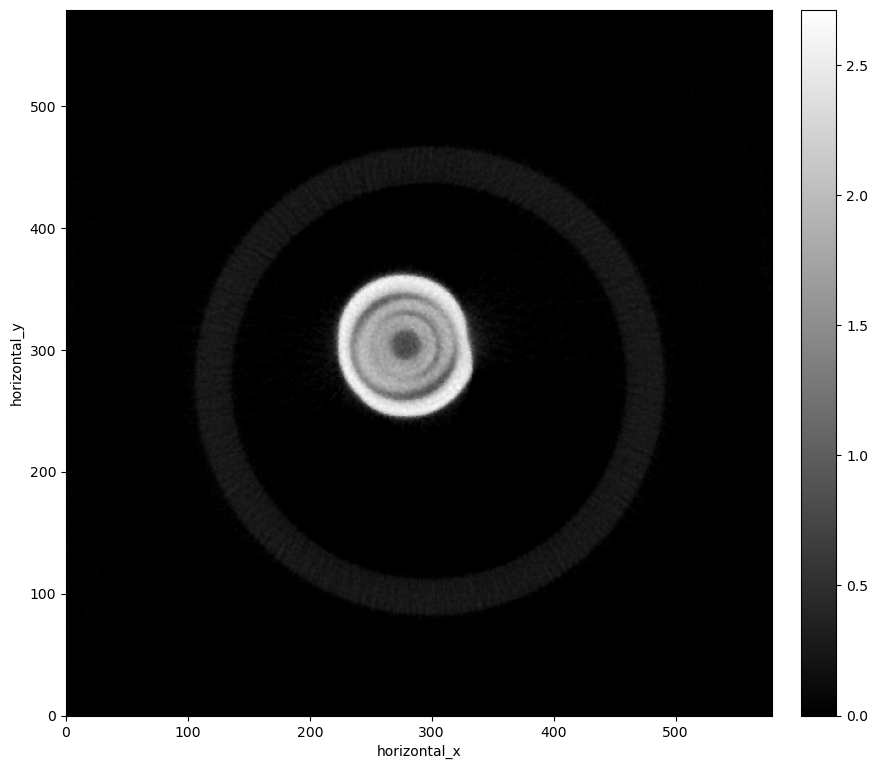

In [16]:
show2D(myPDHG_explicit_NN3.solution)

In [17]:
from pdhg_utils import setup_explicit_TV
ad = gr_slices[0]
ag = ad.geometry
ig = ag.get_ImageGeometry()
A = ProjectionOperator(ig, ag, device="gpu")

K, F = setup_explicit_TV(A, None, ad, omega=1, alpha=5e-5)
G = ZeroFunction()
normK = K.norm()
sigma = 1
tau = 1 / (sigma * normK**2)
G = IndicatorBox(lower=0)

myPDHG_explicit_NN3 = PDHG(f=F,g=G,
        sigma = sigma,
        tau=tau, 
        operator=K, 
        update_objective_interval = 100)
myPDHG_explicit_NN3.run(5000,verbose=2)

alpha =  5e-05


  0%|          | 0/5000 [00:00<?, ?it/s]

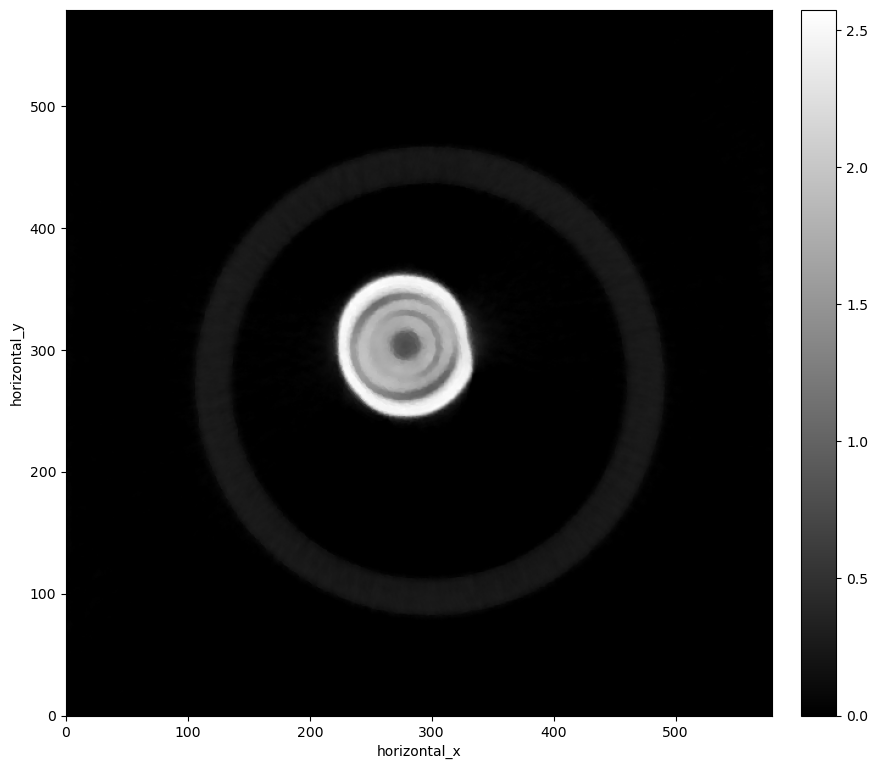

In [18]:
show2D(myPDHG_explicit_NN3.solution)

In [1]:
plt.figure()
plt.loglog(myPDHG_explicit_NN3.iterations[1:], myPDHG_explicit_NN3.objective[1:])
plt.legend(['Without NN', 'With NN'])
plt.grid()
plt.xlabel('Number of iterations')
plt.ylabel('Objective value')


NameError: name 'plt' is not defined